# Basic Ocean Surface Temperature

Create a CMIP7 monthly sea surface temperature file (`tos_tavg-u-hxy-sea`) on a global 10 degree latitude-longitude grid.

In [1]:
from pathlib import Path
import calendar
import json
import shutil

import cmor
from IPython.display import display
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import xarray as xr

TABLES_DIR = "../cmip7-cmor-tables/tables"
CV_PATH = "../cmip7-cmor-tables/tables-cvs/cmor-cvs.json"
DATA_PATH = Path("data") / "tos_Omon_CanCM4_decadal1982_r5i1p1_198301-198310.nc"
if not Path(TABLES_DIR).exists():
    raise FileNotFoundError(f"CMIP7 tables directory not found: {TABLES_DIR}")
if not Path(CV_PATH).exists():
    raise FileNotFoundError(f"CMIP7 CV file not found: {CV_PATH}")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Source data file not found: {DATA_PATH}")



def month_year_label(time_coord):
    decoded_time = xr.coding.times.decode_cf_datetime(
        time_coord.values[:1],
        time_coord.attrs["units"],
        calendar=time_coord.attrs.get("calendar", "standard"),
    )[0]
    if hasattr(decoded_time, "strftime"):
        return decoded_time.strftime("%B %Y")
    date_text = np.datetime_as_string(decoded_time, unit="D")
    year, month = date_text.split("-")[:2]
    return f"{calendar.month_name[int(month)]} {year}"


print(f"Using CMIP7 tables from {TABLES_DIR}")


Using CMIP7 tables from ../cmip7-cmor-tables/tables


In [2]:
with xr.open_dataset(DATA_PATH, decode_times=False) as opened:
    source = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=80,
):
    display(source)


<xarray.Dataset> Size: 2MB
Dimensions:    (time: 10, bnds: 2, lat: 192, lon: 256)
Coordinates:
  * time       (time) float64 80B 4.856e+04 4.859e+04 ... 4.88e+04 4.883e+04
  * lat        (lat) float64 2kB -89.43 -88.29 -87.15 ... 87.15 88.29 89.43
  * lon        (lon) float64 2kB 0.7031 2.109 3.516 4.922 ... 356.5 357.9 359.3
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) float64 160B 4.854e+04 4.858e+04 ... 4.885e+04
    lat_bnds   (lat, bnds) float64 3kB -90.0 -88.86 -88.86 ... 88.86 88.86 90.0
    lon_bnds   (lon, bnds) float64 4kB 0.0 1.406 1.406 ... 358.6 358.6 360.0
    tos        (time, lat, lon) float32 2MB nan nan nan ... 271.2 271.2 271.2
Attributes:
    institution:            CCCma (Canadian Centre for Climate Modelling and ...
    institute_id:           CCCma
    experiment_id:          decadal1982
    source:                 CanCM4 2010 atmosphere: CanAM4 (AGCM15i, T63L35) ...
    model_id:               CanCM4
    forcing:                GHG,Oz,SA,BC,OC,LU,Sl,Vl (GHG includes CO2,CH4,N2...
    parent_experiment_id:   N/A
    parent_experiment_rip:  N/A
    branch_time:            0.0
    contact:                cccma_info@ec.gc.ca
    references:             http://www.cccma.ec.gc.ca/models
    initialization_method:  1
    physics_version:        1
    tracking_id:            5152f593-3451-453f-9c5f-b45e46a2efc0
    branch_time_YMDH:       1983:01:01:00
    CCCma_runid:            DHFP1B_E005_I1983_M01
    CCCma_parent_runid:     DHFP1_E005
    CCCma_data_licence:     1) GRANT OF LICENCE - The Government of Canada (E...
    product:                output
    experiment:             10- or 30-year run initialized in year 1982
    frequency:              mon
    creation_date:          2011-07-13T02:25:29Z
    history:                2011-07-13T02:25:29Z CMOR rewrote data to comply ...
    Conventions:            CF-1.4
    project_id:             CMIP5
    table_id:               Table Omon (28 March 2011) d71862c6fdafa47720d8a4...
    title:                  CanCM4 model output prepared for CMIP5 10- or 30-...
    parent_experiment:      N/A
    modeling_realm:         ocean
    realization:            5
    cmor_version:           2.5.4

In [3]:
run_dir = Path("output") / "01_basic_ocean_surface_temperature"
if run_dir.exists():
    shutil.rmtree(run_dir)
output_dir = run_dir / "cmor_output"
output_dir.mkdir(parents=True)

DATASET_INFO = {
    "_AXIS_ENTRY_FILE": "CMIP7_coordinate.json",
    "_FORMULA_VAR_FILE": "CMIP7_formula_terms.json",
    "_cmip7_option": 1,
    "_controlled_vocabulary_file": CV_PATH,
    "activity_id": "CMIP",
    "calendar": source["time"].attrs.get("calendar", "standard"),
    "experiment_id": "amip",
    "forcing_index": "f3",
    "frequency": "mon",
    "grid_label": "g999",
    "host_collection": "CMIP7",
    "initialization_index": "i1",
    "institution_id": "CCCma",
    "license_id": "CC-BY-4.0",
    "nominal_resolution": "100 km",
    "outpath": str(output_dir),
    "physics_index": "p1",
    "realization_index": "r9",
    "region": "glb",
    "source_id": "DUMMY-MODEL",
}
input_json = run_dir / "input.json"
input_json.write_text(json.dumps(DATASET_INFO, indent=2, sort_keys=True))

lat = source["lat"].values.astype("f8")
lat_bnds = source["lat_bnds"].values.astype("f8")
lon = source["lon"].values.astype("f8")
lon_bnds = source["lon_bnds"].values.astype("f8")
time = source["time"].values.astype("f8")
time_bnds = source["time_bnds"].values.astype("f8")
time_units = source["time"].attrs["units"]

missing_value = np.float32(1.0e20)
tos_kelvin = source["tos"].values.astype("f4")
tos = np.where(np.isfinite(tos_kelvin), tos_kelvin - np.float32(273.15), missing_value).astype("f4")

print(tos.shape)


(10, 192, 256)


In [4]:
cmor.setup(
    inpath=TABLES_DIR,
    netcdf_file_action=cmor.CMOR_REPLACE,
    logfile=str(run_dir / "cmor.log"),
)
cmor.dataset_json(str(input_json))
cmor.load_table("CMIP7_ocean.json")

lat_id = cmor.axis("latitude", coord_vals=lat, cell_bounds=lat_bnds, units="degrees_north")
lon_id = cmor.axis("longitude", coord_vals=lon, cell_bounds=lon_bnds, units="degrees_east")
time_id = cmor.axis("time", coord_vals=time, cell_bounds=time_bnds, units=time_units)

variable_name = "tos_tavg-u-hxy-sea"
tos_id = cmor.variable(variable_name, "degC", [time_id, lat_id, lon_id], missing_value=missing_value)
compound_name = ".".join(["ocean"] + variable_name.split("_") + ["mon", "glb"])

with open(Path(TABLES_DIR) / "CMIP7_cell_measures.json") as handle:
    cell_measure = json.load(handle)["cell_measures"].get(compound_name)
if cell_measure:
    cmor.set_variable_attribute(tos_id, "cell_measures", "c", cell_measure)

with open(Path(TABLES_DIR) / "CMIP7_long_name_overrides.json") as handle:
    long_name = json.load(handle)["long_name_overrides"].get(compound_name)
if long_name:
    cmor.set_variable_attribute(tos_id, "long_name", "c", long_name)

cmor.write(tos_id, tos)
netcdf_path = Path(cmor.close(tos_id, file_name=True))
cmor.close()

print(netcdf_path.resolve().relative_to(Path.cwd().resolve()))


output/01_basic_ocean_surface_temperature/cmor_output/MIP-DRS7/CMIP7/CMIP/CCCma/DUMMY-MODEL/amip/r9i1p1f3/glb/mon/tos/tavg-u-hxy-sea/g999/v20260531/tos_tavg-u-hxy-sea_mon_glb_g999_DUMMY-MODEL_amip_r9i1p1f3_198301-198310.nc


In [5]:
with xr.open_dataset(netcdf_path, decode_times=False) as opened:
    ds = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=80,
):
    display(ds)

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 10, bnds: 2, lat: 192, lon: 256)
Coordinates:
  * time       (time) float64 80B 4.856e+04 4.859e+04 ... 4.88e+04 4.883e+04
  * lat        (lat) float64 2kB -89.43 -88.29 -87.15 ... 87.15 88.29 89.43
  * lon        (lon) float64 2kB 0.7031 2.109 3.516 4.922 ... 356.5 357.9 359.3
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) float64 160B 4.854e+04 4.858e+04 ... 4.885e+04
    lat_bnds   (lat, bnds) float64 3kB -90.0 -88.86 -88.86 ... 88.86 88.86 90.0
    lon_bnds   (lon, bnds) float64 4kB 0.0 1.406 1.406 ... 358.6 358.6 360.0
    tos        (time, lat, lon) float32 2MB nan nan nan ... -1.95 -1.95 -1.95
Attributes:
    Conventions:           CF-1.12
    activity_id:           CMIP
    area_label:            sea
    branded_variable:      tos_tavg-u-hxy-sea
    branding_suffix:       tavg-u-hxy-sea
    creation_date:         2026-05-31T18:59:17Z
    data_specs_version:    MIP-DS7.1.0.0
    description:           Simulation of the climate of the recent past with ...
    drs_specs:             MIP-DRS7
    experiment:            Simulation of the climate of the recent past with ...
    experiment_id:         amip
    external_variables:    areacello
    forcing_index:         f3
    frequency:             mon
    grid_label:            g999
    history:               2026-05-31T18:59:17Z ; CMOR rewrote data to be con...
    horizontal_label:      hxy
    host_collection:       CMIP7
    initialization_index:  i1
    institution:           Environment and Climate Change Canada
    institution_id:        CCCma
    license_id:            CC-BY-4.0
    mip_era:               CMIP7
    nominal_resolution:    100 km
    physics_index:         p1
    product:               model-output
    realization_index:     r9
    realm:                 ocean
    region:                glb
    source:                DUMMY-MODEL: aerosol: Dummy Aerosol; atmosphere: D...
    source_id:             DUMMY-MODEL
    table_info:            Name: CMIP7_ocean.json; Creation Date:(2026-04-21 ...
    temporal_label:        tavg
    title:                 DUMMY-MODEL output prepared for CMIP7
    tracking_id:           hdl:21.14107/416e223a-d2e9-42e9-85e1-4ebbd0e29d8e
    variable_id:           tos
    variant_label:         r9i1p1f3
    vertical_label:        u
    license:               CC-BY-4.0; CMIP7 data produced by CCCma is license...
    cmor_version:          3.15.1

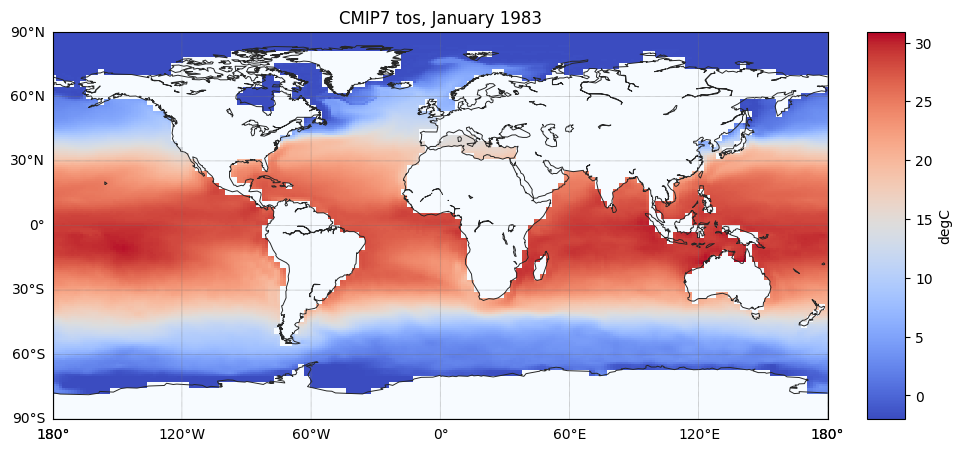

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.4))
map_plot = Basemap(
    projection="cyl",
    llcrnrlon=-180,
    urcrnrlon=180,
    llcrnrlat=-90,
    urcrnrlat=90,
    resolution="c",
    ax=ax,
)
map_plot.drawmapboundary(fill_color="#f7fbff", linewidth=0.8)
lon_wrapped = ((ds["lon"].values + 180.0) % 360.0) - 180.0
lon_order = np.argsort(lon_wrapped)
lon_grid, lat_grid = np.meshgrid(lon_wrapped[lon_order], ds["lat"].values)
x, y = map_plot(lon_grid, lat_grid)
field = ds["tos"].isel(time=0).values[:, lon_order]
mesh = map_plot.pcolormesh(x, y, field, shading="auto", cmap="coolwarm")
map_plot.drawcoastlines(linewidth=0.7, color="0.15")
map_plot.drawparallels(np.arange(-90, 91, 30), labels=[1, 0, 0, 0], linewidth=0.4, color="0.45", dashes=[1, 1])
map_plot.drawmeridians(np.arange(-180, 181, 60), labels=[0, 0, 0, 1], linewidth=0.4, color="0.45", dashes=[1, 1])
colorbar = map_plot.colorbar(mesh, location="right", pad="5%")
colorbar.set_label("degC")
time_label = month_year_label(ds["time"])
ax.set_title(f"CMIP7 tos, {time_label}")
plt.show()
